In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../data/AdultCensusIncomeDataset/adult.csv")

In [3]:
RS = 42

In [4]:
Drop_list_for_x_data = ['income']

In [5]:
X = data.drop(Drop_list_for_x_data , axis=1)

In [6]:
y = data['income'].copy().to_frame()

In [7]:
from sklearn.model_selection import train_test_split

X_train , X_valid , y_train , y_valid = train_test_split(X , y , test_size=0.1 , stratify=data['income'] , random_state=RS)

In [8]:
X_train

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
9829,28,Private,338376,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States
7600,20,Private,221095,HS-grad,9,Never-married,Craft-repair,Other-relative,Black,Male,0,0,40,United-States
24113,34,Private,177596,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,Puerto-Rico
19430,28,Private,197113,HS-grad,9,Never-married,Machine-op-inspct,Own-child,Other,Male,0,0,50,Puerto-Rico
14322,38,Private,199816,HS-grad,9,Divorced,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21312,36,Private,150601,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,?
24250,25,Private,256620,Bachelors,13,Separated,Exec-managerial,Not-in-family,White,Male,0,0,40,United-States
25812,18,Self-emp-not-inc,157131,11th,7,Never-married,Sales,Own-child,White,Female,0,0,40,United-States
7468,35,Private,334291,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States


In [9]:
X_categorial_Types = X.select_dtypes(include=['object']).columns

In [10]:
X_numerical_types = X.select_dtypes(include=['int64']).columns

In [11]:
from pandas.plotting import scatter_matrix
# scatter_matrix(X_train[X_numerical_types] , figsize=(20 , 20))

In [12]:
from sklearn.preprocessing import OrdinalEncoder , StandardScaler , LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline ,Pipeline 

In [13]:
numerical_pipeline = Pipeline(
    [
        ('scaler' , StandardScaler())
    ]
)

categorial_pipeline = Pipeline(
    [
        ('cat_to_num' , OrdinalEncoder(  handle_unknown='error'))
    ]
)
Y_pipeline = Pipeline(
    [
        ('cat' ,  OrdinalEncoder(handle_unknown='error'))
    ]
)

In [14]:
preprocessing_pipeline = ColumnTransformer(
    [
        ('cat' , categorial_pipeline , X_categorial_Types),
        ('num', numerical_pipeline , X_numerical_types)
    ]
)

In [15]:
X_train = preprocessing_pipeline.fit_transform(X_train)

In [16]:
y_train = Y_pipeline.fit_transform(y_train)
y_train = y_train[: ,0]

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
lr_model = LogisticRegression(random_state=RS)

In [19]:
lr_model.fit(X_train , y_train)

c:\Users\kuoro\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_valid = Y_pipeline.fit_transform(y_valid)
X_valid = preprocessing_pipeline.fit_transform(X_valid)

In [21]:
from sklearn.metrics import roc_auc_score

In [22]:
y_pred = lr_model.predict(X_valid)

In [23]:
roc_auc_score(y_valid , y_pred)

0.7054858285813315

(array([2757.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         500.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

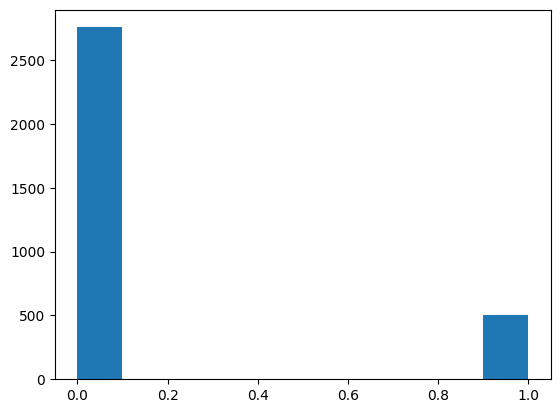

In [24]:
plt.hist(y_pred)

(array([2473.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         784.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

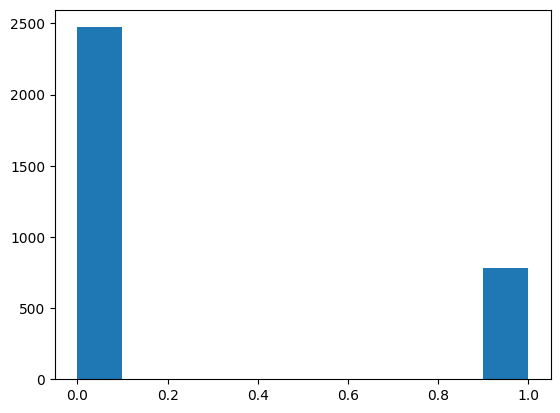

In [25]:
plt.hist(y_valid)